Labels found in Raven table: ['bt', 'mt', 'st']
Call band from 342 annotations: 16.0-400.0 Hz -> fmin=15, fmax=400

########## CALIBRATION: baseline  (fmin=0, fmax=500, norm=False) ##########

=== frame_dur = 0.096s ===
  n_mels=26  n_mfcc=15
  search_len = 1.744s
  st: threshold=21.8431  F1=0.766
  mt: threshold=23.2477  F1=0.352
  bt: threshold=23.8800  F1=0.368

=== frame_dur = 0.128s ===
  n_mels=26  n_mfcc=15
  search_len = 1.76s
  st: threshold=20.5057  F1=0.779
  mt: threshold=22.2208  F1=0.357
  bt: threshold=23.2919  F1=0.356

=== frame_dur = 0.192s ===
  n_mels=26  n_mfcc=15
  search_len = 1.744s
  st: threshold=18.8208  F1=0.827
  mt: threshold=22.6071  F1=0.363
  bt: threshold=21.2366  F1=0.442

=== frame_dur = 0.256s ===
  n_mels=26  n_mfcc=15
  search_len = 1.792s
  st: threshold=18.4589  F1=0.815
  mt: threshold=22.7041  F1=0.393
  bt: threshold=21.7202  F1=0.472

=== frame_dur = 0.384s ===
  n_mels=26  n_mfcc=15
  search_len = 1.792s
  st: threshold=17.8017  F1=0.851
  

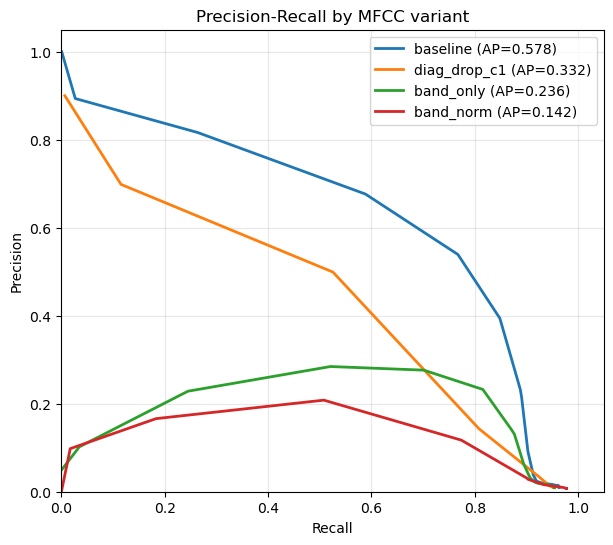

In [1]:
"""
mfcc_v2_experiment.py
=====================
Standalone script: improved MFCC extractor + your calibration notebook logic
+ your test notebook logic, for several variants so you can compare them.

Only NEW or CHANGED code lives here. Unchanged functions are imported from
your existing modules (feature, calibration, testing).

Run:  python mfcc_v2_experiment.py
"""
from pathlib import Path
import math

import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt

# ---- unchanged functions from your existing modules -----------------------
from feature import FeatureExtractor, load_features_from_json
from calibration import (
    load_entries,
    load_template_features_fixed_length,
    frame_hop_len,
    dtw_cross_costs_time,
    compute_pr_curve_from_costs,
    find_threshold_best_f1_from_pr,
    plot_dtw_scatter,
    plot_pr_curve_from_costs,
    save_model_config,
)
from testing import (
    load_model_config,
    load_all_template_features_new,
    load_raven_selection_table,
    get_exclusion_intervals,
    detection_pipeline,
    match_detections,
    compute_pr_curve_alpha_new,
    compute_average_precision,
)

# ===========================================================================
# SETTINGS
# ===========================================================================
N_CALIB = 10          # calibration templates per call type
N_BG = 100            # background clips
N_TEMPS = 10          # templates used for voting
FS_NEW = 1000
SLACK_S = 0.512       # same slack as your notebook
FEAT_FRAME_LENGTHS = [0.096, 0.128, 0.192, 0.256, 0.384, 0.512]
CALL_TYPES = ["st", "mt", "bt"]
VOTE_FRACS = np.round(np.arange(1, N_TEMPS + 1) / N_TEMPS, 2).tolist()

# Labels in the Raven "Call" column that count as calls (used to find the band)
CALL_LABELS = ("st", "mt", "bt")
BAND_ROUND_TO = 5     # round fmin down / fmax up to a multiple of this (Hz)
MAX_MELS = 24         # upper limit on n_mels
MIN_MELS = 6          # warn if the rule gives fewer than this

# Test settings. Lower N_HOURS (e.g. 6) for a quick smoke test, but then
# numbers are not comparable with your 72 h baseline.
N_HOURS = 72
ALPHA_MAX = 3.0
RUN_TEST = True
SHOW_CALIB_PLOTS = False   # scatter + PR plots for the chosen frame length

# Variants. "band" for fmin/fmax means "use the band measured from Raven".
# n_mels / n_mfcc = None means "use the rule" (n_mels <= (fmax-fmin)*frame_dur,
# n_mfcc = n_mels // 2).
VARIANTS = {
    # Reproduces your current extractor (0-500 Hz, 26 mels, 15 coeffs)
    "baseline":     dict(fmin=0, fmax=500, n_mels=26, n_mfcc=15, norm=False, drop_extra=0),
    # Diagnostic: baseline with the dominant first coefficient removed
    "diag_drop_c1": dict(fmin=0, fmax=500, n_mels=26, n_mfcc=15, norm=False, drop_extra=1),
    # Steps 2 + 3 only
    "band_only":    dict(fmin="band", fmax="band", n_mels=None, n_mfcc=None, norm=False, drop_extra=0),
    # Steps 1 + 2 + 3
    "band_norm":    dict(fmin="band", fmax="band", n_mels=None, n_mfcc=None, norm=True, drop_extra=0),
}
VARIANTS_TO_RUN = ["baseline", "diag_drop_c1", "band_only", "band_norm"]

# ---- paths (same as your notebooks) ---------------------------------------
RESULTS = Path(r"C:\Users\HP\Desktop\Skripsie data\Results")

DATA_26 = Path(r"C:\Users\HP\Desktop\Skripsie data\26")
RESULTS_26 = DATA_26 / "template_selections"
RAVEN_26 = DATA_26 / "2023-04-26T07-55-05_000_00072.txt"   # calibration recording

DATA_29 = Path(r"C:\Users\HP\Desktop\Skripsie data\29")
RESULTS_29 = DATA_29 / "template_selections"

DATA_22 = Path(r"C:\Users\HP\Desktop\Skripsie data\22")    # test recording
RAVEN_22 = DATA_22 / "2023-04-22T17-13-01_000_00070.txt"
WAV_22 = DATA_22 / "20230422_171301.wav"

BG_FILE = "Bground_CALIB_26_20230426_075505_background.json"
CALIB_FILES = {
    "st": "ST_CALIB_26_20230426_075505_single_tone_templates.json",
    "mt": "MT_CALIB_26_20230426_075505_multi_tone_templates.json",
    "bt": "BT_CALIB_26_20230426_075505_burst_tonal_templates.json",
}
TEMP_FILES = {
    "st": "20230429_Templates_20230429_102841_single_tone_templates.json",
    "mt": "20230429_Templates_20230429_102841_multi_tone_templates.json",
    "bt": "20230429_Templates_20230429_102841_burst_tonal_templates.json",
}
TEMPLATE_FILE_LABEL = "20230429_Templates"
TEMPLATE_RECORDING_LABEL = "20230429_102841"


# ===========================================================================
# NEW: call band from the Raven table (Step 2)
# ===========================================================================
def get_call_band(raven_path, labels=CALL_LABELS, lo_q=0.05, hi_q=0.95,
                  round_to=BAND_ROUND_TO, nyquist=FS_NEW / 2):
    """
    Empirical call band: 5th percentile of 'Low Freq (Hz)' and 95th percentile
    of 'High Freq (Hz)' over labelled calls, rounded outward.
    Uses the CALIBRATION recording only, so the test recording is not used
    to design the feature.
    """
    df = pd.read_csv(raven_path, sep="\t")
    df["Call"] = df["Call"].astype(str).str.strip().str.lower()
    df = df.drop_duplicates(subset=["Selection", "Begin Time (s)", "End Time (s)", "Call"])
    print(f"Labels found in Raven table: {sorted(df['Call'].unique())}")

    sel = df[df["Call"].isin(labels)]
    if sel.empty:
        print(f"WARNING: none of {labels} found; using every label except 'td'.")
        sel = df[df["Call"] != "td"]

    lo = sel["Low Freq (Hz)"].quantile(lo_q)
    hi = sel["High Freq (Hz)"].quantile(hi_q)
    fmin = max(0.0, math.floor(lo / round_to) * round_to)
    fmax = min(float(nyquist), math.ceil(hi / round_to) * round_to)
    print(f"Call band from {len(sel)} annotations: {lo:.1f}-{hi:.1f} Hz "
          f"-> fmin={fmin:.0f}, fmax={fmax:.0f}")
    return float(fmin), float(fmax)


# ===========================================================================
# NEW: MFCC extractor v2 (Steps 1, 2, 3)
# ===========================================================================
def make_mfcc_extractor_v2(frame_dur=0.128, fmin=20.0, fmax=150.0,
                           n_mels=None, n_mfcc=None, overlap=0.75,
                           drop_c0=True, drop_extra=0, metric="euclidean",
                           norm_stats=None):
    """
    fmin/fmax   : mel band edges (Hz), taken from the call band.
    n_mels      : None -> int(min(MAX_MELS, (fmax-fmin)*frame_dur)), so no
                  mel filter is narrower than one FFT bin (bin spacing = 1/frame_dur).
    n_mfcc      : None -> n_mels // 2, so the DCT actually compresses.
    drop_extra  : drop this many extra low coefficients after c0 (diagnostic).
    norm_stats  : (mean_list, std_list) per coefficient from background clips.
                  Applied identically to templates and the continuous stream.
    """
    fmin, fmax = float(fmin), float(fmax)
    if n_mels is None:
        n_mels = int(min(MAX_MELS, (fmax - fmin) * frame_dur))
        if n_mels < MIN_MELS:
            print(f"WARNING: frame_dur={frame_dur}s over {fmin:.0f}-{fmax:.0f} Hz "
                  f"allows only {n_mels} mels; using {MIN_MELS}.")
            n_mels = MIN_MELS
    if n_mfcc is None:
        n_mfcc = max(3, n_mels // 2)

    if norm_stats is not None:
        mu = np.asarray(norm_stats[0], dtype=float)[:, None]
        sd = np.asarray(norm_stats[1], dtype=float)[:, None]
    else:
        mu = sd = None

    def fn(audio, fs):
        n_fft = int(fs * frame_dur)
        hop = int(n_fft * (1 - overlap))
        S = librosa.feature.melspectrogram(
            y=audio.astype(np.float32), sr=fs, n_fft=n_fft, hop_length=hop,
            window="hamming", n_mels=n_mels, fmin=fmin, fmax=fmax)
        m = librosa.feature.mfcc(S=librosa.power_to_db(S, top_db=None),
                                 n_mfcc=n_mfcc + int(drop_c0))
        if drop_c0:
            m = m[1:]
        m = m[drop_extra:]
        if mu is not None:
            m = (m - mu) / (sd + 1e-9)
        return m

    params = dict(
        frame_dur=float(frame_dur), overlap=float(overlap),
        fmin=fmin, fmax=fmax, n_mels=int(n_mels), n_mfcc=int(n_mfcc),
        drop_c0=bool(drop_c0), drop_extra=int(drop_extra),
        norm_stats=None if norm_stats is None else
        [list(map(float, norm_stats[0])), list(map(float, norm_stats[1]))],
    )
    return FeatureExtractor("mfcc", fn, min_duration=frame_dur, metric=metric,
                            params=params, batch_fn=None)


def extractor_from_params(p):
    """Rebuild an extractor from the 'params' stored in the model config."""
    return make_mfcc_extractor_v2(
        frame_dur=p["frame_dur"], overlap=p["overlap"],
        fmin=p["fmin"], fmax=p["fmax"],
        n_mels=p["n_mels"], n_mfcc=p["n_mfcc"],
        drop_c0=p["drop_c0"], drop_extra=p["drop_extra"],
        norm_stats=p["norm_stats"])


# ===========================================================================
# NEW: normalisation statistics (Step 1)
# ===========================================================================
def fit_norm_stats(feat_list):
    """Per-coefficient mean/std over ALL frames of ALL background clips."""
    allf = np.concatenate(feat_list, axis=1)          # (n_coeffs, total_frames)
    mu = allf.mean(axis=1)
    sd = np.maximum(allf.std(axis=1), 1e-6)
    return mu.tolist(), sd.tolist()


def apply_norm_stats(feat_list, stats):
    mu = np.asarray(stats[0])[:, None]
    sd = np.asarray(stats[1])[:, None]
    return [(f - mu) / (sd + 1e-9) for f in feat_list]


# ===========================================================================
# Helpers
# ===========================================================================
def resolve_variant(v, band):
    fmin = band[0] if v["fmin"] == "band" else v["fmin"]
    fmax = band[1] if v["fmax"] == "band" else v["fmax"]
    return float(fmin), float(fmax)


def load_all_times():
    bg_times = load_entries(RESULTS_26 / BG_FILE, N_BG)
    calib_times = {t: load_entries(RESULTS_26 / CALIB_FILES[t], N_CALIB) for t in CALL_TYPES}
    return bg_times, calib_times


def choose_vote_frac(cost_mats, thresholds):
    """
    cost_mats[(set_name, temp_type)] -> (n_temps, n_clips).
    Same logic as your notebook: best worst-case F1 over all
    (template type, threshold type) combinations.
    k uses round() to match detection_pipeline (the notebook used ceil).
    """
    f1_scores = {}
    for vf in VOTE_FRACS:
        k = max(1, round(vf * N_TEMPS))
        for temp_type in CALL_TYPES:
            for thr_type in CALL_TYPES:
                thr = thresholds[thr_type]
                pos = np.concatenate([
                    (cost_mats[(s, temp_type)] <= thr).sum(axis=0) >= k for s in CALL_TYPES])
                neg = (cost_mats[("bg", temp_type)] <= thr).sum(axis=0) >= k
                tp, fn, fp = pos.sum(), (~pos).sum(), neg.sum()
                p = tp / (tp + fp) if (tp + fp) else 0.0
                r = tp / (tp + fn) if (tp + fn) else 0.0
                f1_scores[(vf, temp_type, thr_type)] = 2 * p * r / (p + r) if (p + r) else 0.0
    best_vf = max(VOTE_FRACS, key=lambda v: (
        min(f1_scores[(v, t, th)] for t in CALL_TYPES for th in CALL_TYPES), v))
    return best_vf, f1_scores


# ===========================================================================
# CALIBRATION  (your calibration notebook, for one variant)
# ===========================================================================
def run_calibration(name, v, band, bg_times, calib_times):
    fmin, fmax = resolve_variant(v, band)
    print(f"\n########## CALIBRATION: {name}  (fmin={fmin:.0f}, fmax={fmax:.0f}, norm={v['norm']}) ##########")

    results, cache, search_lens = {}, {}, {}

    for frame_length in FEAT_FRAME_LENGTHS:
        print(f"\n=== frame_dur = {frame_length}s ===")
        raw_ext = make_mfcc_extractor_v2(
            frame_dur=frame_length, fmin=fmin, fmax=fmax,
            n_mels=v["n_mels"], n_mfcc=v["n_mfcc"], drop_extra=v["drop_extra"])
        hop_s = frame_hop_len(raw_ext, FS_NEW)
        print(f"  n_mels={raw_ext.params['n_mels']}  n_mfcc={raw_ext.params['n_mfcc']}")

        # raw (un-normalised) features
        temp_feats = {t: load_features_from_json(RESULTS_29 / TEMP_FILES[t], raw_ext, N_TEMPS)
                      for t in CALL_TYPES}
        max_tmpl_s = max(f.shape[1] for fl in temp_feats.values() for f in fl) * hop_s
        search_len = round(max_tmpl_s + 2 * SLACK_S, 3)
        search_lens[frame_length] = search_len
        print(f"  search_len = {search_len}s")

        calib_feats = {t: [load_template_features_fixed_length(tpl, raw_ext, search_len, FS_NEW)
                           for tpl in calib_times[t]] for t in CALL_TYPES}
        bg_feats = [load_template_features_fixed_length(tpl, raw_ext, search_len, FS_NEW)
                    for tpl in bg_times]

        # Step 1: fit stats on background, apply to everything (equivalent to
        # rebuilding the extractor with norm_stats, but no reloading needed)
        stats = None
        if v["norm"]:
            stats = fit_norm_stats(bg_feats)
            bg_feats = apply_norm_stats(bg_feats, stats)
            for t in CALL_TYPES:
                temp_feats[t] = apply_norm_stats(temp_feats[t], stats)
                calib_feats[t] = apply_norm_stats(calib_feats[t], stats)

        extractor = make_mfcc_extractor_v2(
            frame_dur=frame_length, fmin=fmin, fmax=fmax,
            n_mels=v["n_mels"], n_mfcc=v["n_mfcc"], drop_extra=v["drop_extra"],
            norm_stats=stats)

        cache[frame_length] = dict(extractor=extractor, hop_s=hop_s, temp_feats=temp_feats,
                                   calib_feats=calib_feats, bg_feats=bg_feats)

        results[frame_length] = {}
        for t in CALL_TYPES:
            call_costs, _, _ = dtw_cross_costs_time(
                temp_feats[t], calib_feats[t], hop_s, frame_length, extractor.metric)
            bg_costs, _, _ = dtw_cross_costs_time(
                temp_feats[t], bg_feats, hop_s, frame_length, extractor.metric)
            precision, recall, pr_thr = compute_pr_curve_from_costs(call_costs, bg_costs)
            threshold, f1 = find_threshold_best_f1_from_pr(precision, recall, pr_thr)
            results[frame_length][t] = dict(threshold=threshold, f1=f1,
                                            call_costs=call_costs, bg_costs=bg_costs)
            print(f"  {t}: threshold={threshold:.4f}  F1={f1:.3f}")   # (indented: prints every type)

    # choose frame length: best worst-case F1 across call types
    frame_scores = {f: min(r["f1"] for r in results[f].values()) for f in results}
    best_fl = max(frame_scores, key=lambda f: (frame_scores[f], f))
    best_score = frame_scores[best_fl]
    thresholds = {t: results[best_fl][t]["threshold"] for t in CALL_TYPES}
    print(f"\nChosen frame length: {best_fl}   worst-case F1: {best_score:.3f}")
    print("Thresholds:", {k: round(v_, 4) for k, v_ in thresholds.items()})

    if SHOW_CALIB_PLOTS:
        fig, axes = plt.subplots(2, 3, figsize=(15, 8))
        for col, t in enumerate(CALL_TYPES):
            r = results[best_fl][t]
            plot_dtw_scatter(r["call_costs"], r["bg_costs"], threshold=r["threshold"], ax=axes[0, col])
            plot_pr_curve_from_costs(r["call_costs"], r["bg_costs"], best_threshold=r["threshold"], ax=axes[1, col])
            axes[0, col].set_title(f"{name} {t.upper()} costs")
            axes[1, col].set_title(f"{name} {t.upper()} PR")
        plt.tight_layout()
        plt.show()

    # vote fraction (DTW once per clip set x template type)
    c = cache[best_fl]
    clip_sets = dict(c["calib_feats"])
    clip_sets["bg"] = c["bg_feats"]
    cost_mats = {}
    for set_name, clips in clip_sets.items():
        for temp_type in CALL_TYPES:
            temps = c["temp_feats"][temp_type]
            flat, _, _ = dtw_cross_costs_time(temps, clips, c["hop_s"], best_fl, c["extractor"].metric)
            cost_mats[(set_name, temp_type)] = np.asarray(flat).reshape(len(temps), len(clips))
    best_vf, f1_scores = choose_vote_frac(cost_mats, thresholds)
    print(f"Best vote_frac: {best_vf}")

    config_path = RESULTS / f"model_config_mfcc_v2_{name}_{N_TEMPS}.json"
    save_model_config(
        config_path, feat_method="mfcc", extractor=c["extractor"], fs_new=FS_NEW,
        best_frame_len=best_fl, search_len_s=search_lens[best_fl],
        thresholds=thresholds, best_vote_frac=best_vf, n_temps=N_TEMPS, n_calib=N_CALIB,
        best_f1=best_score, vote_f1_scores=f1_scores, template_files=TEMP_FILES)

    return dict(config_path=config_path, extractor=c["extractor"], best_fl=best_fl,
                best_f1=best_score, thresholds=thresholds, vote_frac=best_vf)


# ===========================================================================
# TEST  (your test notebook, for one variant)
# ===========================================================================
def run_test(name, cal):
    print(f"\n########## TEST: {name} ##########")
    cfg = load_model_config(cal["config_path"])
    fs_new = cfg["feature"]["fs_new"]
    frame_len = cfg["feature"]["frame_len"]
    vote_frac = cfg["best_vote_frac"]
    n_temps = cfg["n_temps"]
    thr = cfg["thresholds"]

    extractor = extractor_from_params(cfg["feature"]["params"])

    # round-trip check: saved config must rebuild the identical extractor
    rng = np.random.default_rng(0)
    probe = rng.standard_normal(int(fs_new * 6)).astype(np.float32)
    assert np.allclose(extractor(probe, fs_new), cal["extractor"](probe, fs_new)), \
        "Rebuilt extractor differs from calibration extractor!"
    print("Config round-trip OK")
    print(f"frame={frame_len}  vote_frac={vote_frac}  n_temps={n_temps}  thresholds={thr}")

    hop_s = frame_hop_len(extractor, fs_new)
    min_sep_s = 2 * frame_len

    st_feats, mt_feats, bt_feats = load_all_template_features_new(
        results_dir=RESULTS_29, file_label=TEMPLATE_FILE_LABEL,
        recording_label=TEMPLATE_RECORDING_LABEL,
        extractor=extractor, n_temps=n_temps, fs_new=fs_new)

    raven_table = load_raven_selection_table(RAVEN_22)
    td_intervals = get_exclusion_intervals(raven_table, exclude_labels=("td",), pad=0.1)

    starts, ends, scaled_costs, labels = detection_pipeline(
        audio_file=WAV_22, n_hours=N_HOURS,
        st_feats=st_feats, mt_feats=mt_feats, bt_feats=bt_feats,
        st_threshold=thr["st"], mt_threshold=thr["mt"], bt_threshold=thr["bt"],
        exclude_intervals=td_intervals, extractor=extractor, fs_new=fs_new,
        vote_frac=vote_frac, hop_s=hop_s, frame_s=frame_len,
        min_sep_s=min_sep_s, alpha_max=ALPHA_MAX)

    t_max = N_HOURS * 3600.0
    raven_no_td = [g for g in raven_table if g["label"] != "td" and g["start"] < t_max]

    is_call = scaled_costs <= 1.0
    calls = [(float(s), float(e), lab) for s, e, lab in
             zip(starts[is_call], ends[is_call], labels[is_call])]
    tp_det, fp, tp_calls, fn, false_pos, _ = match_detections(calls, raven_no_td)
    P = tp_det / (tp_det + fp) if (tp_det + fp) else 0.0
    R = tp_calls / (tp_calls + fn) if (tp_calls + fn) else 0.0
    print(f"deployed: calls={len(calls)}  P={P:.3f}  R={R:.3f}")

    alphas = np.unique(np.append(np.linspace(0.1, ALPHA_MAX, 40), 1.0))
    p1, r1, used = compute_pr_curve_alpha_new(starts, ends, scaled_costs, labels, raven_no_td, alphas)
    ap = compute_average_precision(p1, r1)
    print(f"AP = {ap:.3f}")

    # where do the false positives sit relative to labelled calls?
    if len(false_pos):
        gt_s = np.array([g["start"] for g in raven_no_td])
        gt_e = np.array([g["end"] for g in raven_no_td])
        gaps = np.array([np.maximum(0, np.maximum(gt_s - e, s - gt_e)).min() for s, e, _ in false_pos])
        print(f"False positives: {len(gaps)}  "
              f"(<2 s from a call: {((gaps > 0) & (gaps < 2)).mean():.1%}, "
              f">=2 s away: {(gaps >= 2).mean():.1%})")

    return dict(P=P, R=R, ap=ap, n_calls=len(calls), p_curve=p1, r_curve=r1,
                P_at_1=P, R_at_1=R)


# ===========================================================================
# MAIN
# ===========================================================================
def main():
    band = get_call_band(RAVEN_26)
    bg_times, calib_times = load_all_times()

    summary, curves = {}, {}
    for name in VARIANTS_TO_RUN:
        cal = run_calibration(name, VARIANTS[name], band, bg_times, calib_times)
        row = dict(frame_len=cal["best_fl"], calib_F1=round(cal["best_f1"], 3),
                   vote_frac=cal["vote_frac"])
        if RUN_TEST:
            res = run_test(name, cal)
            row.update(test_P=round(res["P"], 3), test_R=round(res["R"], 3),
                       test_AP=round(res["ap"], 3), n_calls=res["n_calls"])
            curves[name] = (res["r_curve"], res["p_curve"], res["ap"])
        summary[name] = row

    print("\n================ SUMMARY ================")
    print(pd.DataFrame(summary).T.to_string())

    if curves:
        plt.figure(figsize=(7, 6))
        for name, (r, p, ap) in curves.items():
            order = np.argsort(r)
            plt.plot(np.asarray(r)[order], np.asarray(p)[order], linewidth=2,
                     label=f"{name} (AP={ap:.3f})")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("Precision-Recall by MFCC variant")
        plt.xlim(0, 1.05)
        plt.ylim(0, 1.05)
        plt.grid(alpha=0.3)
        plt.legend()
        plt.show()


if __name__ == "__main__":
    main()